In [ ]:
import numpy as np
import heaan as hn
import time, math
import warnings

warnings.filterwarnings("ignore", category=np.ComplexWarning)
np.set_printoptions(formatter={'float': '{: .10e}'.format}, linewidth=1000)

## 1. HE Environment Setup

In [27]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from engine.HEengine import HEengine
from engine.HEdata import Message, Ciphertext

In [30]:
engine = HEengine()

device_id = 0 ## GPU id
dt = hn.Device(hn.DeviceType.GPU, device_id)

NameError: name 'hn' is not defined

## 2. Chebyshev approx coef generation

In [11]:
def genData(start, middle, end, n):
    a = np.linspace(start, middle, n//2)
    b = np.linspace(middle, end, n//2)
    return np.concatenate((a, b))

In [12]:
def ret_print(x, y, y_eval):
    print("Input\t\t:", x)
    print("Answer\t\t:", y)
    print("Eval ret\t:", y_eval)

    err = y - y_eval
    mre = np.mean(np.abs(err) / np.abs(y))

    print("MRE\t\t:", mre)

--- 31차 체비쇼프 근사 다항식 계수 ---


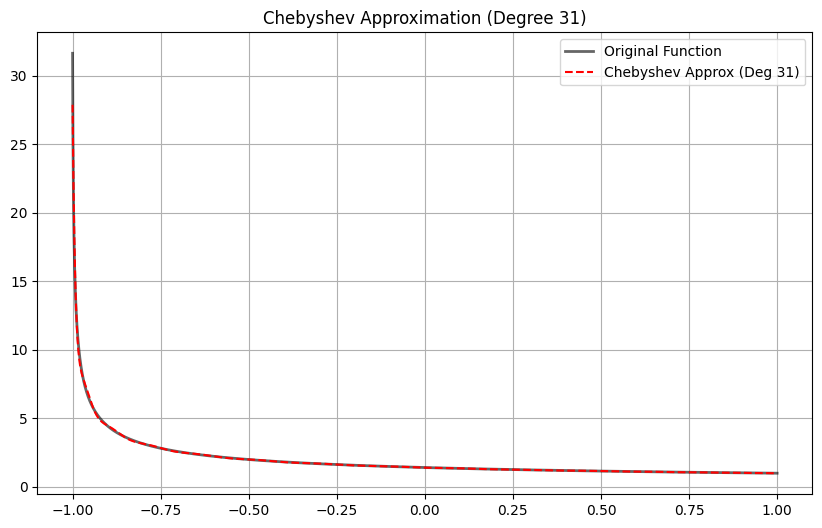


최대 오차 (Max Error): 1.19e-01


(array([-1.      , -0.999998, -0.999996, ...,  0.999996,  0.999998,
         1.      ]),
 array([31.6227766 , 31.60699283, 31.59123268, ...,  1.000001  ,
         1.0000005 ,  1.        ]),
 array([27.8649373 , 27.85981332, 27.85469053, ...,  0.99462082,
         0.99460928,  0.99459772]),
 array([], dtype=float64))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

def get_chebyshev_approximation(target_func, degree, domain):
    approx_poly = Chebyshev.interpolate(target_func, degree, domain=domain)
    return approx_poly

K = 2 # inverse of K-th root

# 1. 설정
log_deg = 5
A = 1 * (10 ** -3)
B = 1 * (10 ** 0)
DEGREE, DOMAIN = 2**log_deg-1, [-1, 1]

def func(h):
    result = []
    for x in h:
        x = (B-A)*x/2+(B+A)/2
        result.append(pow(x, -1/K))
    return np.array(result)    

# 3. 근사 다항식 생성
cheb_poly = get_chebyshev_approximation(func, DEGREE, DOMAIN)

# 4. 결과 확인 (다항식 계수 출력)
print(f"--- {DEGREE}차 체비쇼프 근사 다항식 계수 ---") 

# 5. 시각화 (원본 vs 근사)
x_vals = np.linspace(DOMAIN[0], DOMAIN[1], 1000000)
y_true = func(x_vals)
y_approx = cheb_poly(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_true, 'k-', label='Original Function', linewidth=2, alpha=0.6)
plt.plot(x_vals, y_approx, 'r--', label=f'Chebyshev Approx (Deg {DEGREE})')

plt.title(f"Chebyshev Approximation (Degree {DEGREE})")
plt.legend()
plt.grid(True)
plt.show()

# 6. 오차 확인
error = np.abs(y_true - y_approx) / y_true
print(f"\n최대 오차 (Max Error): {np.max(error):.2e}")
x_vals, y_true, y_approx, y_approx[y_approx<0]

In [16]:
x = np.concatenate([np.linspace(A, (A+B)/2, 10000000), np.linspace((A+B)/2, B, 10000000)])
y_ans = x**(-1/2)

print(f"X\n{x}\n")

trans_x = x*2/(B-A) - (B+A)/(B-A)
cheb_y = cheb_poly(trans_x)
print("First Approx")
print(cheb_y)
print("#Neg\t\t:", len(cheb_y[cheb_y < 0]))
print()

iter = 10
y_iter = np.copy(cheb_y)

for i in range(iter):
    print("#", i+1)
    y_iter = (3/2) * y_iter - (1/2)*x*(y_iter**3)
    ret_print(x, y_ans, y_iter)
    print("Max RE\t\t:", np.max(np.abs((y_ans-y_iter)/y_ans)), f"({np.argmax(np.abs((y_ans-y_iter)/y_ans))})")
    print()

X
[0.001      0.00100005 0.0010001  ... 0.9999999  0.99999995 1.        ]

First Approx
[27.8649373  27.86468107 27.86442485 ...  0.99459888  0.9945983
  0.99459772]
#Neg		: 0

# 1
Input		: [0.001      0.00100005 0.0010001  ... 0.9999999  0.99999995 1.        ]
Answer		: [31.6227766  31.62198685 31.62119716 ...  1.00000005  1.00000002
  1.        ]
Eval ret	: [30.97947476 30.97884849 30.97822226 ...  0.99995637  0.99995634
  0.9999563 ]
MRE		: 0.0001315072561528278
Max RE		: 0.02034299055311335 (0)

# 2
Input		: [0.001      0.00100005 0.0010001  ... 0.9999999  0.99999995 1.        ]
Answer		: [31.6227766  31.62198685 31.62119716 ...  1.00000005  1.00000002
  1.        ]
Eval ret	: [31.60327969 31.60249933 31.60171903 ...  1.00000005  1.00000002
  1.        ]
MRE		: 4.310471959919122e-07
Max RE		: 0.0006165465531836851 (0)

# 3
Input		: [0.001      0.00100005 0.0010001  ... 0.9999999  0.99999995 1.        ]
Answer		: [31.6227766  31.62198685 31.62119716 ...  1.00000005  1.00000002
  1. 

In [32]:
from pathlib import Path

coeff_path = project_root / "coeffs" / "invSqrt_coeffs.py"

try:
    from coeffs.invSqrt_coeffs import _INV_SQRT_COEFFS
    coeffs_dict = dict(_INV_SQRT_COEFFS)
except (ImportError, TypeError, ValueError):
    coeffs_dict = {}

coeffs_dict[DEGREE] = cheb_poly.coef.astype(float).tolist()

lines = ["_INV_SQRT_COEFFS = {"]

for degree in sorted(coeffs_dict):
    coeffs = ", ".join(repr(value) for value in coeffs_dict[degree])
    lines.append(f"    {degree}: [{coeffs}],")

lines.append("}")
lines.append("")

coeff_path.write_text("\n".join(lines), encoding="utf-8")

697

## 3. Invsqrt using inverse n-th root

In [ ]:
data_num = 100_000
test = genData(A, (A+B)/2, B, data_num)

m = Message(test, value=B)
m.to(dt)

In [51]:
test = genData(9*1e-6, (A+B)/2, B, num_slots)

m = hn.Message(test)
m.to(dt)
ct_base = hn.Ciphertext(context)
ect.encrypt(m, pk, ct_base, level=28)
ct_base.to(dt)

ct = hn.Ciphertext(context)
scaled_ct = hn.Ciphertext(context)

evt.mult(ct_base, 1/2, ct)
evt.mult(ct_base, 2/(B-A), scaled_ct)
 
ans = test ** (-1/2)

start = time.time()

"""Approx"""
degree = 2 ** log_deg - 1
cbsp = np.copy(cheb_poly.coef)
evt.sub(scaled_ct, (B+A)/(B-A), scaled_ct)

Bstep = next_power_of_two_sqrt(degree)
cbsp = transform_coeffs4BSGS(cbsp, Bstep, degree)
hn_cbsp = hn.math.approx.ChebyshevCoefficients(np.array(cbsp), Bstep)

ret_ct = hn.math.approx.evaluate_chebyshev_expansion(evt, bts, scaled_ct, hn_cbsp, 1)

"""Newton iteration"""
iteration = 8
ret_ct = HENewtonInv(ct, ret_ct, iteration, ans)

end = time.time()

ret = hn.Message(log_slots)
dct.decrypt(ret_ct, sk, ret)
ret.to_host()

print()
ret = np.array(ret, dtype=np.float64)
ret_print(test, ans, ret)
print("Max RE\t\t:", np.max(np.abs((ans-ret)/ans)), f"({np.argmax(np.abs((ans-ret)/ans))})")
print("\t\t", ret[np.argmax(np.abs((ans-ret)/ans))], ans[np.argmax(np.abs((ans-ret)/ans))])
print("Time\t\t:", end-start)

#0		: [ 3.3205878621e+02  3.3179931958e+02  3.3153724498e+02 ...  3.1620044837e+01  3.1619700237e+01  3.1619357048e+01] (level 22)
MRE		: 0.00012548667698524687
Max RE		: 0.003823641369571078 (0)

#1		: [ 3.3332683969e+02  3.3304681546e+02  3.3276417341e+02 ...  3.1623254438e+01  3.1623015170e+01  3.1622777681e+01] (level 20)
MRE		: 1.720327565916656e-07
Max RE		: 2.985224990584114e-05 (2)

#2		: [ 3.3333417172e+02  3.3305392095e+02  3.3277103945e+02 ...  3.1623254920e+01  3.1623015696e+01  3.1622778235e+01] (level 18)
MRE		: 1.5918895235153897e-07
Max RE		: 1.67761092330136e-05 (110)

#3		: [ 3.3333410855e+02  3.3305390086e+02  3.3277103470e+02 ...  3.1623254930e+01  3.1623015696e+01  3.1622778235e+01] (level 16)
MRE		: 1.59188462825504e-07
Max RE		: 1.679786500667482e-05 (110)

#4		: [ 3.3333413537e+02  3.3305390783e+02  3.3277104267e+02 ...  3.1623254912e+01  3.1623015700e+01  3.1622778221e+01] (level 14)
MRE		: 1.5921740520523733e-07
Max RE		: 1.6754058341567792e-05 (110)

#5		: [ 